# McLachan method

This takes Schrodingers evolution of $\frac{d}{dt} \ket{\psi} = -i H \ket{psi}$


and the state is restricted to an ansatz $\ket{\psi(\theta)}$

McLachan principle is $ \delta || \frac{d}{dt}\ket{\psi(\theta)} + iH\ket{\psi(\theta)} || = 0$

which gives a linear system $M \dot{\theta} = V$.

$M_{ij} = Re(\braket{\mathrm{d}_i \psi | \mathrm{d}_j \psi})$

$V_{i} = Im(\braket{\mathrm{d}_i \psi | H |\psi})$

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import functools as ft

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize

In [13]:
def hamiltonian1(L, Jz):
    """
    Docstring for hamiltonian
    
    :param X: X pauli op
    (X, 0, t)
    :param Y: Y pauli op
    :param Z: Z pauli op
    """
    ham_list = []

    for i in range (int(L)-1):
        ham_list.append(("XX", [i, i+1], -1)) # XX bc Xi and X i+1
        ham_list.append(("YY", [i, i+1], -1))
        ham_list.append(("ZZ", [i, i+1], -Jz))

    H =  SparsePauliOp.from_sparse_list(ham_list, num_qubits=L)

    return H


Jz = 1.1 #can vary

a = 4 #THIS IS L

def initialise(Jz, a):
    """
    Decides L and the initial state to use depending on the value of Jz.
    Returns: L, list of initial Statevectors
    """
    if Jz > 1:
        L = a
        psi_0 = Statevector.from_label("0" * L)
        psi_1 = Statevector.from_label("1" * L)
        return L, [psi_0, psi_1]

    elif Jz < -1:
        L = a
        alternating = "".join(["10"[i % 2] for i in range(L)])
        psi_10 = Statevector.from_label(alternating)
        return L, [psi_10]

    else:
        raise ValueError("Jz must be > 1 or < -1")

L, initial_states = initialise(Jz, a) #L HERE IS WHAT THE TENSOR NUMBER IS

H = hamiltonian1(L, Jz)

In [14]:
def ansatz_circuit(theta, L):
    """ 
    rotations 
    """
    qc = QuantumCircuit(L)
    k = 0

    # qubit rotations ZX rotations to make complex phases
    for q in range(L):
        qc.ry(theta[k], q)
        k += 1
        qc.rz(theta[k], q)
        k += 1

    # entangling layer
    for q in range(L - 1):
        qc.cx(q, q + 1)

    return qc


def psi_theta(theta, L):
    qc = ansatz_circuit(theta, L)
    return Statevector(qc).data

In [15]:
def fit_theta_to_state(psi_target, L, n_restarts=5):
    """
    Find theta such that psi_theta(theta, L) ≈ psi_target.
    Tries multiple random restarts and returns the best fit.
    """
    best_theta = None
    best_loss = np.inf

    def overlap_loss(theta):
        psi = psi_theta(theta, L)
        return 1.0 - abs(np.vdot(psi_target, psi)) ** 2

    for _ in range(n_restarts):
        theta_init = np.random.uniform(-np.pi, np.pi, 2 * L)
        result = minimize(overlap_loss, theta_init, method="L-BFGS-B")
        if result.fun < best_loss:
            best_loss = result.fun
            best_theta = result.x

    print(f"Initial state fit quality — overlap loss: {best_loss:.6f}  "
          f"(0 = perfect, 1 = orthogonal)")
    return best_theta

we numerically differentiate 

$ \mathrm{d}_i = \frac{\psi(\theta + \epsilon) - \psi(\theta - \epsilon)}{2 \epsilon}$ 

In [16]:
def psi_derivative(theta, i, L, eps=1e-6):
    t_plus  = theta.copy(); t_plus[i]  += eps
    t_minus = theta.copy(); t_minus[i] -= eps
    return (psi_theta(t_plus, L) - psi_theta(t_minus, L)) / (2 * eps)

def build_M(theta, L):
    n = len(theta)
    derivs = [psi_derivative(theta, i, L) for i in range(n)]
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = np.real(np.vdot(derivs[i], derivs[j]))
    return M


def build_V(theta, H, L):
    psi  = psi_theta(theta, L)
    Hpsi = H @ psi
    n = len(theta)
    V = np.zeros(n)
    for i in range(n):
        dpsi = psi_derivative(theta, i, L)
        V[i] = np.imag(np.vdot(dpsi, Hpsi))
    return V

def mclachlan_evolve(theta0, H, L, dt, steps):
    theta  = theta0.copy()
    states = [psi_theta(theta, L)]   # store t=0 state
    reg    = 1e-8

    for _ in range(steps):
        M = build_M(theta, L)
        V = build_V(theta, H, L)
        theta_dot = np.linalg.solve(M + reg * np.eye(len(theta)), V)
        theta += dt * theta_dot
        states.append(psi_theta(theta, L))

    return states

In [17]:
pauli_x = np.array([[0, 1],  [1,  0]],  dtype=complex)
pauli_y = np.array([[0, -1j],[1j, 0]],  dtype=complex)
pauli_z = np.array([[1, 0],  [0, -1]],  dtype=complex)
identity = np.eye(2, dtype=complex)


def observable_matrix(L, qubit, pauli):
    ops = [identity] * L
    ops[qubit] = pauli
    return ft.reduce(np.kron, ops)


def expectation_value(psi, observable):
    return np.real(np.vdot(psi, observable @ psi))


def measure_direction(states, L, pauli):
    observables = [observable_matrix(L, q, pauli) for q in range(L)]
    data = np.zeros((L, len(states)))
    for t, psi in enumerate(states):
        for q in range(L):
            data[q, t] = expectation_value(psi, observables[q])
    return data

Initial state fit quality — overlap loss: 0.000000  (0 = perfect, 1 = orthogonal)


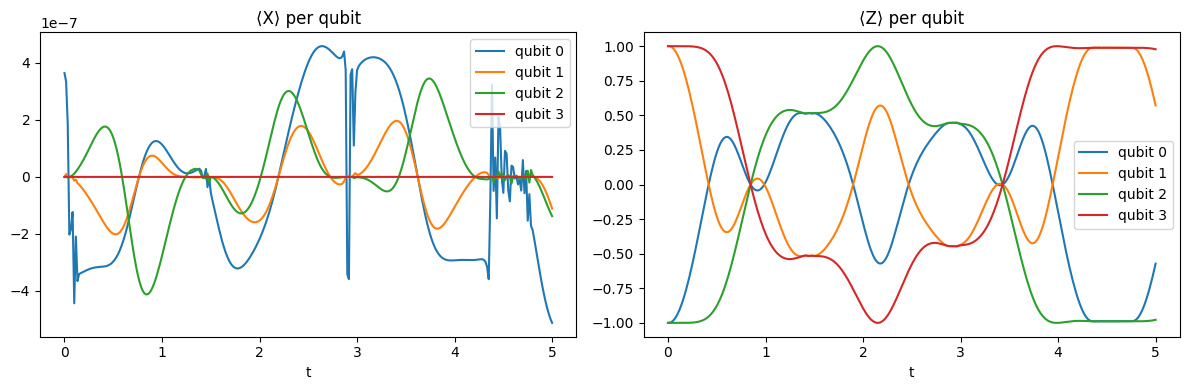

X magnetisation data shape: (4, 301)
[[ 3.64326992e-07  3.34774783e-07  1.86276727e-07 ... -4.81625734e-07
  -4.98539824e-07 -5.12279424e-07]
 [ 3.48338204e-14  1.00064075e-08 -2.73955497e-09 ... -7.83871288e-08
  -9.43990372e-08 -1.11271150e-07]
 [ 2.19730424e-15  1.55665834e-09 -2.67717066e-09 ... -1.12989004e-07
  -1.25948268e-07 -1.37731389e-07]
 [-2.83186961e-15 -6.38596657e-15 -6.77334514e-11 ...  5.41959666e-12
   5.16866387e-12  4.90141267e-12]]


In [20]:
Jz = -1.1
a  = 4

# 1. Pick L and the correct initial state for this Jz
L, initial_states = initialise(Jz, a)
psi_target = initial_states[0].data   # Néel state |1010> for Jz < -1

# 2. Build Hamiltonian matrix
H = hamiltonian1(L, Jz).to_matrix()

# 3. Fit theta0 so that the ansatz circuit reproduces psi_target
theta0 = fit_theta_to_state(psi_target, L, n_restarts=5)

# 4. Time-evolve
steps   = 300
t_total = 5.0
dt      = t_total / steps

states = mclachlan_evolve(theta0, H, L, dt, steps)

# 5. Measure and plot
t_values = np.arange(len(states)) * dt   # len = steps+1 (includes t=0)

X_data = measure_direction(states, L, pauli_x)
Z_data = measure_direction(states, L, pauli_z)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for q in range(L):
    axes[0].plot(t_values, X_data[q], label=f"qubit {q}")
axes[0].set_title("⟨X⟩ per qubit")
axes[0].set_xlabel("t")
axes[0].legend()

for q in range(L):
    axes[1].plot(t_values, Z_data[q], label=f"qubit {q}")
axes[1].set_title("⟨Z⟩ per qubit")
axes[1].set_xlabel("t")
axes[1].legend()

plt.tight_layout()
plt.savefig("magnetisation.png", dpi=150)
plt.show()

print("X magnetisation data shape:", X_data.shape)
print(X_data)